# Step 08: Visualization & Storytelling
## Employee Attrition Analysis – IBM HR Dataset

This notebook presents key visual insights derived from exploratory data analysis.
The objective is to translate analytical findings into meaningful business stories
that can guide HR decision-making and support predictive modeling.


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

### Load Clean Dataset

In [2]:
df = pd.read_csv("../01_dataset/raw/IBM_HR_Analytics_Employee_Attrition_Performance.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Attrition Overview - The Big Picture
#### Attrition Count

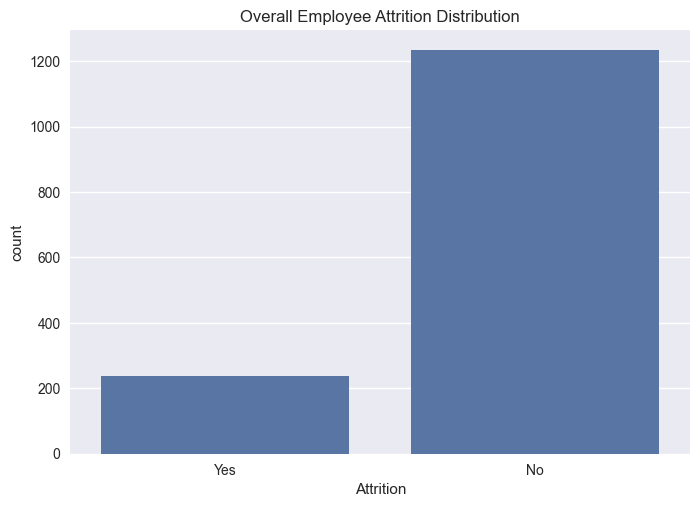

In [3]:
sns.countplot(data=df, x='Attrition')
plt.title('Overall Employee Attrition Distribution')
plt.show()

### Story
The organization shows a noticeable imbalance between employees who stayed
and those who left. This confirms that attrition is a real but minority problem,
which must be handled carefully during predictive modeling.


### Attrition by Department

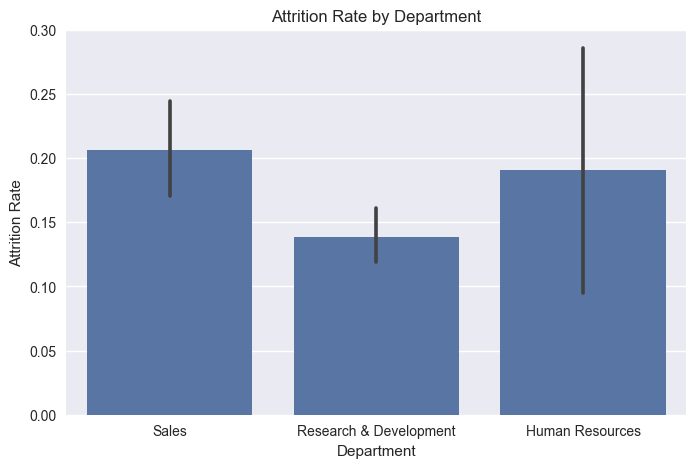

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = df,
    x = 'Department',
    y = df['Attrition'].map({'Yes':1, 'No':0}),
    estimator = np.mean
)

plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate')
plt.show()

### Story

Sales and Human Resources show higher attrition rates compared to R&D.
This suggests role pressure, target-based stress, or limited growth
opportunities in these departments.


### Attrition by Job Role

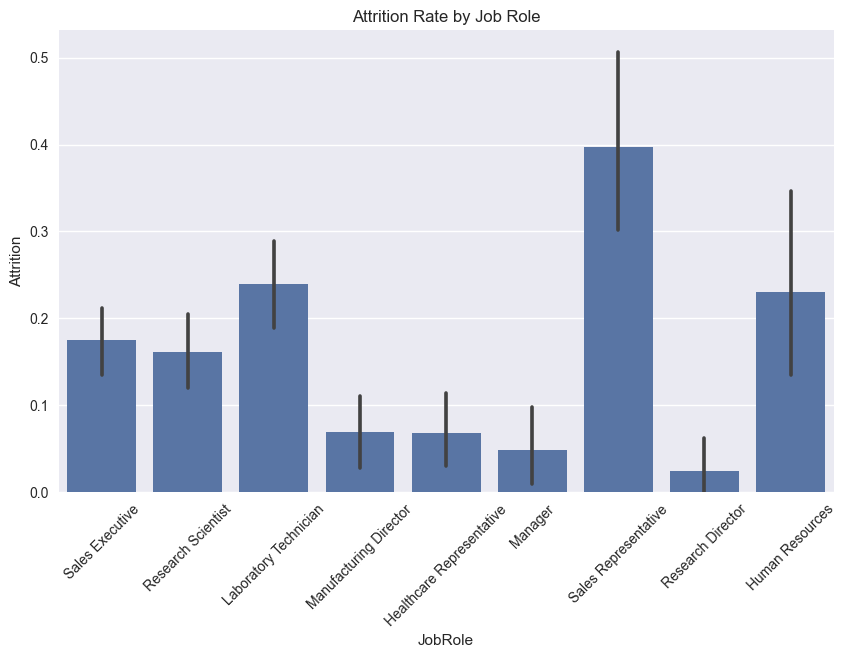

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='JobRole',
    y=df['Attrition'].map({'Yes':1, 'No':0}),
    estimator=np.mean
)

plt.xticks(rotation=45)
plt.title('Attrition Rate by Job Role')
plt.show()


### Story
Laboratory Technician and Sales Representatives exhibit the highest attrition.
These roles often involve shift work, performance pressure, and limited flexibility, making them more vulnerable to employee turnover.

### Overtime vs Attrition

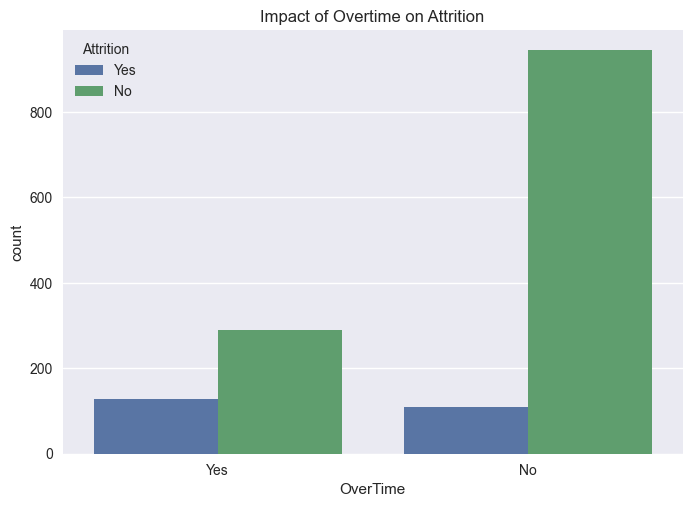

In [7]:
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Impact of Overtime on Attrition')
plt.show()

### Story

Employees working overtime leave at a significantly higher rate.
This confirms work-life balance as one of the strongest drivers of attrition.

### Income vs Attrition

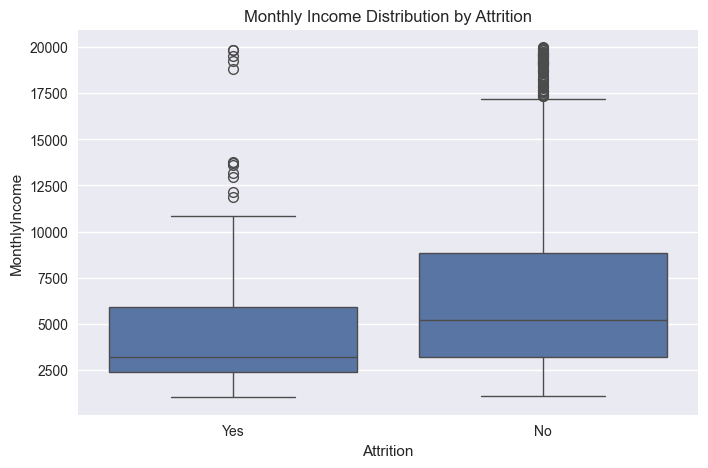

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income Distribution by Attrition')
plt.show()

### Story

- Employees who left the company earned noticeably less on average.
- This highlights compensation dissatisfaction as a major attrition factor.

### Age & Tenure Analysis

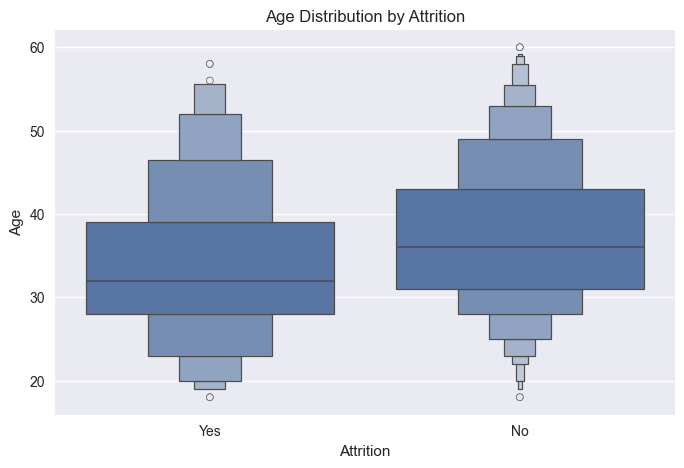

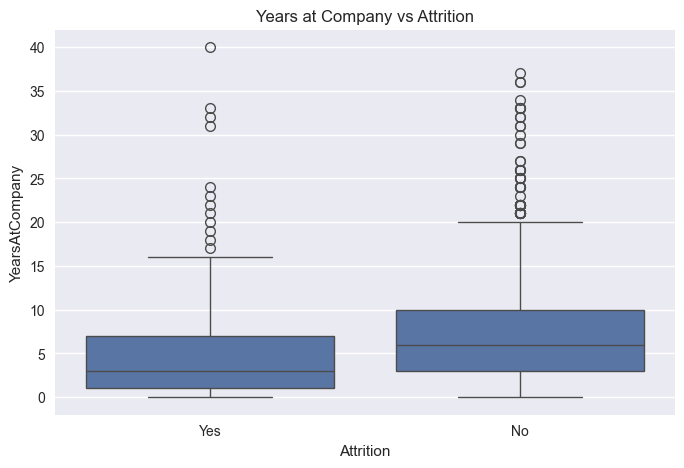

In [9]:
plt.figure(figsize=(8,5))
sns.boxenplot(data=df, x='Attrition', y='Age')
plt.title('Age Distribution by Attrition')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany')
plt.title('Years at Company vs Attrition')
plt.show()

### Story

- Younger employees and those with shorter tenure are more likely to leave.
- This indicates early-career instability and onboarding challenges.

### Correlation Heatmap

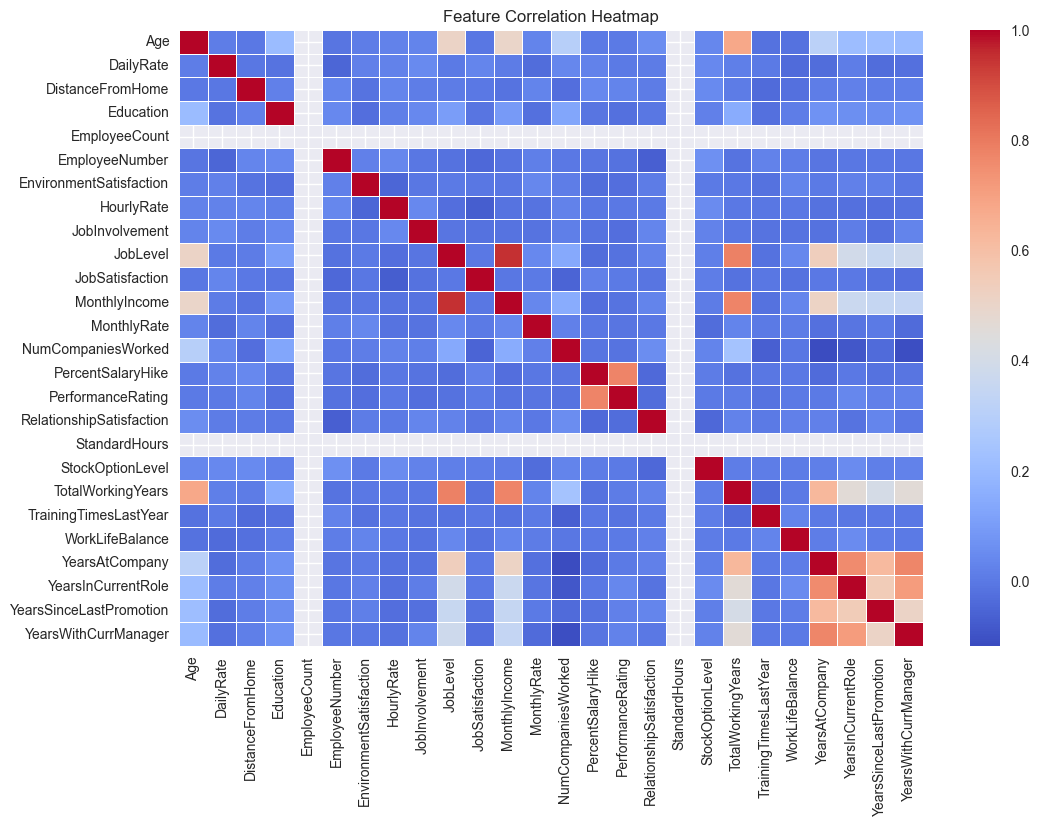

In [10]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### Story

While no single variable dominates, compensation, tenure, and work-life-related variables show meaningful relationships with attrition.
This supports using tree-based and ensemble models for prediction.

### Key Visualization Insights

- Sales and HR departments face higher attrition risk
- Overtime strongly increases attrition probability
- Lower income employees are more likely to leave
- Early-career employees need targeted retention strategies
- Attrition is influenced by multiple interacting factors

These insights justify the need for predictive modeling rather than rule-based logic.


### Next Step

Proceed to **Step 09 – Business Insights & HR Recommendations**, where
visual findings will be converted into actionable strategies for HR teams.
